In [ ]:
import os
import shutil
import time
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm
from tqdm import tqdm
from sklearn.metrics import classification_report

# ==========================================
# 1. EXACT DATASET SORTING 
# ==========================================
print("🔍 Accessing exact Kaggle dataset path...")

# The exact path you provided
base_path = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
csv_path = os.path.join(base_path, 'HAM10000_metadata.csv')
out_dir = '/kaggle/working/ham10000_sorted'

os.makedirs(out_dir, exist_ok=True)

# Map every .jpg image dynamically from inside the exact folder
image_paths = {}
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith('.jpg'):
            image_paths[file] = os.path.join(root, file)

print(f"📄 Found Metadata CSV.")
print(f"🖼️ Found {len(image_paths)} images. Preparing to sort...")

df = pd.read_csv(csv_path)

print("📂 Sorting images into 7 class folders (Takes ~45 seconds)...")
for index, row in tqdm(df.iterrows(), total=df.shape[0]):
    img_name = f"{row['image_id']}.jpg"
    label = row['dx']  # 7 classes: akiec, bcc, bkl, df, mel, nv, vasc
    
    class_dir = os.path.join(out_dir, label)
    os.makedirs(class_dir, exist_ok=True)
    
    if img_name in image_paths:
        shutil.copy(image_paths[img_name], os.path.join(class_dir, img_name))

print("\n✅ Dataset successfully structured for PyTorch!")

# ==========================================
# 2. DATASET PREPARATION
# ==========================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=out_dir, transform=transform)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"📊 Found {num_classes} classes: {class_names}")

# 80/20 Train/Val Split
generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

# Kaggle T4x2 allows for multiple CPU workers to speed up dataloading
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# ==========================================
# 3. LG-ViT ARCHITECTURE
# ==========================================
class LaplacianFilter(nn.Module):
    def __init__(self):
        super().__init__()
        kernel = torch.tensor([[0,  1, 0], 
                               [1, -4, 1], 
                               [0,  1, 0]], dtype=torch.float32)
        self.weight = nn.Parameter(kernel.unsqueeze(0).unsqueeze(0), requires_grad=False)
        
    def forward(self, x):
        x_gray = x.mean(dim=1, keepdim=True)
        return torch.nn.functional.conv2d(x_gray, self.weight, padding=1)

class LG_ViT(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.vit = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=0)
        self.embed_dim = self.vit.num_features
        
        self.edge_extractor = LaplacianFilter()
        self.edge_patch_embed = nn.Conv2d(1, self.embed_dim, kernel_size=16, stride=16)
        
        self.cross_attn = nn.MultiheadAttention(embed_dim=self.embed_dim, num_heads=4, batch_first=True)
        self.layer_norm = nn.LayerNorm(self.embed_dim)
        
        self.classifier = nn.Sequential(
            nn.Linear(self.embed_dim, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        rgb_tokens = self.vit.forward_features(x)
        edges = self.edge_extractor(x)
        edge_tokens = self.edge_patch_embed(edges).flatten(2).transpose(1, 2)
        
        batch_size = edge_tokens.shape[0]
        dummy_cls = torch.zeros(batch_size, 1, self.embed_dim, device=x.device)
        edge_tokens = torch.cat([dummy_cls, edge_tokens], dim=1)

        attn_output, _ = self.cross_attn(query=rgb_tokens, key=edge_tokens, value=edge_tokens)
        fused_tokens = self.layer_norm(rgb_tokens + attn_output)
        
        return self.classifier(fused_tokens[:, 0, :])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LG_ViT(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

# ==========================================
# 4. FAST TRAINING LOOP (10 EPOCHS)
# ==========================================
print(f"\n🚀 Starting LG-ViT Training on {device}...")
best_acc = 0.0
weights_path = '/kaggle/working/best_lgvit_ham10000.pth'

for epoch in range(10):
    model.train()
    correct, total = 0, 0
    
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/10"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    train_acc = correct / total
    
    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    val_acc = val_correct / val_total
    print(f"📈 Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), weights_path)

print(f"\n✅ Training Complete. Best Validation Accuracy: {best_acc:.4f}")

# ==========================================
# 5. FINAL EVALUATION
# ==========================================
model.load_state_dict(torch.load(weights_path))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n📊 Final HAM10000 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import pandas as pd
import timm
from tqdm import tqdm
from sklearn.metrics import classification_report

# ==========================================
# 1. DIRECT-READ DATASET (NO COPYING NEEDED)
# ==========================================
base_path = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
csv_path = os.path.join(base_path, 'HAM10000_metadata.csv')

print("🔍 Mapping direct image paths from input...")
image_path_map = {}
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith('.jpg'):
            image_path_map[file] = os.path.join(root, file)

df = pd.read_csv(csv_path)

# Label encoding
class_names = sorted(df['dx'].unique().tolist())
label_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}
num_classes = len(class_names)
print(f"📊 Detected {num_classes} classes: {class_names}")

class DirectHAM10000Dataset(Dataset):
    def __init__(self, dataframe, image_map, transform=None):
        self.df = dataframe
        self.image_map = image_map
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = f"{row['image_id']}.jpg"
        img_path = self.image_map[img_name]
        
        image = Image.open(img_path).convert("RGB")
        label = label_to_idx[row['dx']]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = DirectHAM10000Dataset(df, image_path_map, transform=transform)

# 80/20 Train/Val Split (Identical Seed 42)
generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# ==========================================
# 2. VANILLA ViT BASELINE
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Training Vanilla ViT Baseline on {device}...")

vanilla_vit = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(vanilla_vit.parameters(), lr=1e-4, weight_decay=1e-2)

best_acc = 0.0
vanilla_weights_path = '/kaggle/working/best_vanilla_vit_ham10000.pth'

for epoch in range(10):
    vanilla_vit.train()
    correct, total = 0, 0
    
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/10"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = vanilla_vit(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    train_acc = correct / total
    
    # Validation
    vanilla_vit.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vanilla_vit(inputs)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    val_acc = val_correct / val_total
    print(f"📈 Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(vanilla_vit.state_dict(), vanilla_weights_path)

print(f"\n✅ Vanilla ViT Training Complete. Best Val Acc: {best_acc:.4f}")

# ==========================================
# 3. EVALUATION REPORT
# ==========================================
vanilla_vit.load_state_dict(torch.load(vanilla_weights_path))
vanilla_vit.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = vanilla_vit(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n📊 Final Vanilla ViT Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

🔍 Mapping direct image paths from input...
📊 Detected 7 classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
🚀 Training Vanilla ViT Baseline on cuda...


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Epoch 1/10: 100%|██████████| 251/251 [01:22<00:00,  3.04it/s]


📈 Epoch 1 | Train Acc: 0.7616 | Val Acc: 0.7963


Epoch 2/10: 100%|██████████| 251/251 [00:44<00:00,  5.58it/s]


...

📈 Epoch 8 | Train Acc: 0.9490 | Val Acc: 0.8617


Epoch 9/10: 100%|██████████| 251/251 [00:44<00:00,  5.58it/s]


📈 Epoch 9 | Train Acc: 0.9579 | Val Acc: 0.8477


Epoch 10/10: 100%|██████████| 251/251 [00:44<00:00,  5.64it/s]


📈 Epoch 10 | Train Acc: 0.9601 | Val Acc: 0.8697

✅ Vanilla ViT Training Complete. Best Val Acc: 0.8697

📊 Final Vanilla ViT Classification Report:
              precision    recall  f1-score   support

       akiec       0.82      0.55      0.66        75
         bcc       0.80      0.78      0.79       105
         bkl       0.73      0.72      0.72       202
          df       0.88      0.78      0.82        27
         mel       0.61      0.67      0.64       228
          nv       0.93      0.94      0.93      1339
        vasc       0.96      0.89      0.92        27

    accuracy                           0.86      2003
   macro avg       0.82      0.76      0.78      2003
weighted avg       0.86      0.86      0.86      2003



In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
import timm
from tqdm import tqdm
from sklearn.metrics import classification_report

# ==========================================
# 1. DIRECT DATASET LOADER & CLASS WEIGHTS
# ==========================================
base_path = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
csv_path = os.path.join(base_path, 'HAM10000_metadata.csv')

print("🔍 Mapping direct image paths...")
image_path_map = {}
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith('.jpg'):
            image_path_map[file] = os.path.join(root, file)

df = pd.read_csv(csv_path)

class_names = sorted(df['dx'].unique().tolist())
label_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}
num_classes = len(class_names)

# Compute inverse class frequencies to handle severe class imbalance
class_counts = df['dx'].value_counts().sort_index().values
weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
class_weights = (weights / weights.sum() * num_classes).cuda()

print(f"📊 Detected {num_classes} classes: {class_names}")
print(f"⚖️ Applied Inverse Class Weights: {class_weights.cpu().numpy().round(2)}")

class DirectHAM10000Dataset(Dataset):
    def __init__(self, dataframe, image_map, transform=None):
        self.df = dataframe
        self.image_map = image_map
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = f"{row['image_id']}.jpg"
        img_path = self.image_map[img_name]
        
        image = Image.open(img_path).convert("RGB")
        label = label_to_idx[row['dx']]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = DirectHAM10000Dataset(df, image_path_map, transform=transform)

# Exact identical 80/20 train/val split (Seed 42)
generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# ==========================================
# 2. UPGRADED LG-ViT v2 ARCHITECTURE
# ==========================================
class LearnableDualEdgeExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        # Sobel X & Y (1st Order) + Laplacian (2nd Order)
        sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        laplacian = torch.tensor([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=torch.float32).view(1, 1, 3, 3)
        
        self.sobel_x = nn.Parameter(sobel_x, requires_grad=True)
        self.sobel_y = nn.Parameter(sobel_y, requires_grad=True)
        self.laplacian = nn.Parameter(laplacian, requires_grad=True)
        
        self.proj = nn.Conv2d(3, 1, kernel_size=1)

    def forward(self, x):
        x_gray = x.mean(dim=1, keepdim=True)
        sx = torch.nn.functional.conv2d(x_gray, self.sobel_x, padding=1)
        sy = torch.nn.functional.conv2d(x_gray, self.sobel_y, padding=1)
        lap = torch.nn.functional.conv2d(x_gray, self.laplacian, padding=1)
        
        combined = torch.cat([sx, sy, lap], dim=1)
        return self.proj(combined)

class LG_ViT_v2(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.vit = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=0)
        self.embed_dim = self.vit.num_features
        
        self.edge_extractor = LearnableDualEdgeExtractor()
        self.edge_patch_embed = nn.Conv2d(1, self.embed_dim, kernel_size=16, stride=16)
        
        self.cross_attn = nn.MultiheadAttention(embed_dim=self.embed_dim, num_heads=4, batch_first=True)
        self.layer_norm = nn.LayerNorm(self.embed_dim)
        
        # Learnable residual gate factor
        self.alpha = nn.Parameter(torch.tensor(0.5))
        
        self.classifier = nn.Sequential(
            nn.Linear(self.embed_dim, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        rgb_tokens = self.vit.forward_features(x)
        edges = self.edge_extractor(x)
        edge_tokens = self.edge_patch_embed(edges).flatten(2).transpose(1, 2)
        
        batch_size = edge_tokens.shape[0]
        dummy_cls = torch.zeros(batch_size, 1, self.embed_dim, device=x.device)
        edge_tokens = torch.cat([dummy_cls, edge_tokens], dim=1)

        attn_out, _ = self.cross_attn(query=rgb_tokens, key=edge_tokens, value=edge_tokens)
        fused = self.layer_norm(rgb_tokens + self.alpha * attn_out)
        
        return self.classifier(fused[:, 0, :])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LG_ViT_v2(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

# ==========================================
# 3. TRAINING LOOP (10 EPOCHS)
# ==========================================
print(f"🚀 Training LG-ViT v2 on {device}...")
best_acc = 0.0
weights_path = '/kaggle/working/best_lgvit_v2_ham10000.pth'

for epoch in range(10):
    model.train()
    correct, total = 0, 0
    
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/10"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    train_acc = correct / total
    
    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    val_acc = val_correct / val_total
    print(f"📈 Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Alpha Gate: {model.alpha.item():.3f}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), weights_path)

print(f"\n✅ LG-ViT v2 Training Complete. Best Val Acc: {best_acc:.4f}")

# ==========================================
# 4. FINAL EVALUATION REPORT
# ==========================================
model.load_state_dict(torch.load(weights_path))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n📊 Final LG-ViT v2 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

🔍 Mapping direct image paths...
📊 Detected 7 classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
⚖️ Applied Inverse Class Weights: [0.94 0.6  0.28 2.68 0.28 0.05 2.17]
🚀 Training LG-ViT v2 on cuda...


Epoch 1/10: 100%|██████████| 251/251 [00:52<00:00,  4.78it/s]


📈 Epoch 1 | Train Acc: 0.5473 | Val Acc: 0.6995 | Alpha Gate: 0.505


Epoch 2/10: 100%|██████████| 251/251 [00:50<00:00,  4.93it/s]


📈 Epoch 2 | Train Acc: 0.6472 | Val Acc: 0.5946 | Alpha Gate: 0.505


...

📈 Epoch 8 | Train Acc: 0.7696 | Val Acc: 0.7659 | Alpha Gate: 0.495


Epoch 9/10: 100%|██████████| 251/251 [00:50<00:00,  5.01it/s]


📈 Epoch 9 | Train Acc: 0.7786 | Val Acc: 0.6580 | Alpha Gate: 0.492


Epoch 10/10: 100%|██████████| 251/251 [00:50<00:00,  4.97it/s]


📈 Epoch 10 | Train Acc: 0.7886 | Val Acc: 0.7129 | Alpha Gate: 0.492

✅ LG-ViT v2 Training Complete. Best Val Acc: 0.7888

📊 Final LG-ViT v2 Classification Report:
              precision    recall  f1-score   support

       akiec       0.69      0.51      0.58        75
         bcc       0.68      0.80      0.73       105
         bkl       0.49      0.79      0.60       202
          df       0.78      0.67      0.72        27
         mel       0.54      0.49      0.51       228
          nv       0.93      0.86      0.90      1339
        vasc       0.74      0.96      0.84        27

    accuracy                           0.79      2003
   macro avg       0.69      0.72      0.70      2003
weighted avg       0.82      0.79      0.80      2003



In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
import timm
from tqdm import tqdm
from sklearn.metrics import classification_report

# ==========================================
# 1. BALANCED SQUARE-ROOT CLASS WEIGHTS
# ==========================================
base_path = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
csv_path = os.path.join(base_path, 'HAM10000_metadata.csv')

image_path_map = {}
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith('.jpg'):
            image_path_map[file] = os.path.join(root, file)

df = pd.read_csv(csv_path)
class_names = sorted(df['dx'].unique().tolist())
label_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}
num_classes = len(class_names)

# Smooth square-root weighting (prevents majority collapse)
class_counts = df['dx'].value_counts().sort_index().values
sqrt_weights = np.sqrt(np.max(class_counts) / class_counts)
class_weights = torch.tensor(sqrt_weights, dtype=torch.float).cuda()
class_weights = class_weights / class_weights.sum() * num_classes

print(f"📊 Smooth Class Weights: {class_weights.cpu().numpy().round(2)}")

class DirectHAM10000Dataset(Dataset):
    def __init__(self, dataframe, image_map, transform=None):
        self.df = dataframe
        self.image_map = image_map
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = f"{row['image_id']}.jpg"
        img_path = self.image_map[img_name]
        
        image = Image.open(img_path).convert("RGB")
        label = label_to_idx[row['dx']]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Identical Split (Seed 42)
generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(df))
val_size = len(df) - train_size

full_ds = DirectHAM10000Dataset(df, image_path_map)
train_subset, val_subset = random_split(full_ds, [train_size, val_size], generator=generator)

# Separate train/val transforms
train_dataset = DirectHAM10000Dataset(df.iloc[train_subset.indices].reset_index(drop=True), image_path_map, transform=transform_train)
val_dataset = DirectHAM10000Dataset(df.iloc[val_subset.indices].reset_index(drop=True), image_path_map, transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# ==========================================
# 2. LG-ViT ARCHITECTURE (FAST CONVERGENCE)
# ==========================================
class LaplacianEdgeExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        laplacian = torch.tensor([[0,  1, 0], 
                                  [1, -4, 1], 
                                  [0,  1, 0]], dtype=torch.float32).view(1, 1, 3, 3)
        self.laplacian = nn.Parameter(laplacian, requires_grad=False)

    def forward(self, x):
        x_gray = x.mean(dim=1, keepdim=True)
        return torch.nn.functional.conv2d(x_gray, self.laplacian, padding=1)

class LG_ViT_Production(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.vit = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=0)
        self.embed_dim = self.vit.num_features
        
        self.edge_extractor = LaplacianEdgeExtractor()
        self.edge_patch_embed = nn.Conv2d(1, self.embed_dim, kernel_size=16, stride=16)
        
        self.cross_attn = nn.MultiheadAttention(embed_dim=self.embed_dim, num_heads=4, batch_first=True)
        self.layer_norm = nn.LayerNorm(self.embed_dim)
        
        self.classifier = nn.Sequential(
            nn.Linear(self.embed_dim * 2, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        rgb_tokens = self.vit.forward_features(x)
        edges = self.edge_extractor(x)
        edge_tokens = self.edge_patch_embed(edges).flatten(2).transpose(1, 2)
        
        batch_size = edge_tokens.shape[0]
        dummy_cls = torch.zeros(batch_size, 1, self.embed_dim, device=x.device)
        edge_tokens = torch.cat([dummy_cls, edge_tokens], dim=1)

        attn_out, _ = self.cross_attn(query=rgb_tokens, key=edge_tokens, value=edge_tokens)
        fused = self.layer_norm(rgb_tokens + attn_out)
        
        # Concat CLS tokens from RGB + Fused stream for richer representations
        cls_combined = torch.cat([rgb_tokens[:, 0, :], fused[:, 0, :]], dim=-1)
        return self.classifier(cls_combined)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LG_ViT_Production(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

# ==========================================
# 3. TRAINING LOOP
# ==========================================
print(f"🚀 Training LG-ViT Balanced on {device}...")
best_acc = 0.0
weights_path = '/kaggle/working/best_lgvit_balanced.pth'

for epoch in range(10):
    model.train()
    correct, total = 0, 0
    
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/10"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    scheduler.step()
    train_acc = correct / total
    
    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    val_acc = val_correct / val_total
    current_lr = scheduler.get_last_lr()[0]
    print(f"📈 Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.6f}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), weights_path)

print(f"\n✅ Training Complete. Best Val Acc: {best_acc:.4f}")

# ==========================================
# 4. EVALUATION REPORT
# ==========================================
model.load_state_dict(torch.load(weights_path))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n📊 Final Balanced LG-ViT Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

📊 Smooth Class Weights: [1.11 0.88 0.61 1.87 0.6  0.24 1.68]
🚀 Training LG-ViT Balanced on cuda...


Epoch 1/10: 100%|██████████| 251/251 [00:49<00:00,  5.07it/s]


📈 Epoch 1 | Train Acc: 0.6720 | Val Acc: 0.7479 | LR: 0.000195


Epoch 2/10: 100%|██████████| 251/251 [00:50<00:00,  5.02it/s]


📈 Epoch 2 | Train Acc: 0.7426 | Val Acc: 0.7444 | LR: 0.000181


...

📈 Epoch 8 | Train Acc: 0.8813 | Val Acc: 0.8103 | LR: 0.000020


Epoch 9/10: 100%|██████████| 251/251 [00:50<00:00,  5.01it/s]


📈 Epoch 9 | Train Acc: 0.9038 | Val Acc: 0.8258 | LR: 0.000006


Epoch 10/10: 100%|██████████| 251/251 [00:49<00:00,  5.07it/s]


📈 Epoch 10 | Train Acc: 0.9115 | Val Acc: 0.8367 | LR: 0.000001

✅ Training Complete. Best Val Acc: 0.8367

📊 Final Balanced LG-ViT Classification Report:
              precision    recall  f1-score   support

       akiec       0.60      0.67      0.63        75
         bcc       0.75      0.73      0.74       105
         bkl       0.69      0.74      0.72       202
          df       0.72      0.67      0.69        27
         mel       0.56      0.69      0.62       228
          nv       0.94      0.89      0.92      1339
        vasc       1.00      0.96      0.98        27

    accuracy                           0.84      2003
   macro avg       0.75      0.77      0.76      2003
weighted avg       0.85      0.84      0.84      2003



In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
import timm
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ==========================================
# 1. STRATIFIED 70/15/15 DATA SPLIT
# ==========================================
base_path = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
csv_path = os.path.join(base_path, 'HAM10000_metadata.csv')

print("🔍 Mapping dataset and executing stratified splits...")
image_path_map = {f: os.path.join(root, f) 
                  for root, dirs, files in os.walk(base_path) 
                  for f in files if f.endswith('.jpg')}

df = pd.read_csv(csv_path)
class_names = sorted(df['dx'].unique().tolist())
label_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}
num_classes = len(class_names)

# Step A: Split 70% Train, 30% Temp (Val + Test)
df_train, df_temp = train_test_split(df, test_size=0.30, random_state=42, stratify=df['dx'])

# Step B: Split the 30% Temp into 15% Val and 15% Test
df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=42, stratify=df_temp['dx'])

print(f"📊 Dataset Split Complete:")
print(f"   Train: {len(df_train)} images | Val: {len(df_val)} images | Test: {len(df_test)} images")

# Square-root class weighting based ONLY on training distribution
class_counts = df_train['dx'].value_counts().sort_index().values
sqrt_weights = np.sqrt(np.max(class_counts) / class_counts)
class_weights = torch.tensor(sqrt_weights, dtype=torch.float).cuda()
class_weights = class_weights / class_weights.sum() * num_classes

class DirectHAM10000Dataset(Dataset):
    def __init__(self, dataframe, image_map, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_map = image_map
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = f"{row['image_id']}.jpg"
        img_path = self.image_map[img_name]
        
        image = Image.open(img_path).convert("RGB")
        label = label_to_idx[row['dx']]
        
        if self.transform:
            image = self.transform(image)
        return image, label

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(DirectHAM10000Dataset(df_train, image_path_map, transform_train), batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(DirectHAM10000Dataset(df_val, image_path_map, transform_test), batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(DirectHAM10000Dataset(df_test, image_path_map, transform_test), batch_size=32, shuffle=False, num_workers=2)

# ==========================================
# 2. LG-ViT ARCHITECTURE
# ==========================================
class LaplacianEdgeExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        laplacian = torch.tensor([[0,  1, 0], [1, -4, 1], [0,  1, 0]], dtype=torch.float32).view(1, 1, 3, 3)
        self.laplacian = nn.Parameter(laplacian, requires_grad=False)

    def forward(self, x):
        return torch.nn.functional.conv2d(x.mean(dim=1, keepdim=True), self.laplacian, padding=1)

class LG_ViT_Production(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.vit = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=0)
        self.embed_dim = self.vit.num_features
        self.edge_extractor = LaplacianEdgeExtractor()
        self.edge_patch_embed = nn.Conv2d(1, self.embed_dim, kernel_size=16, stride=16)
        self.cross_attn = nn.MultiheadAttention(embed_dim=self.embed_dim, num_heads=4, batch_first=True)
        self.layer_norm = nn.LayerNorm(self.embed_dim)
        self.classifier = nn.Sequential(
            nn.Linear(self.embed_dim * 2, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        rgb_tokens = self.vit.forward_features(x)
        edges = self.edge_extractor(x)
        edge_tokens = torch.cat([torch.zeros(x.shape[0], 1, self.embed_dim, device=x.device), 
                                 self.edge_patch_embed(edges).flatten(2).transpose(1, 2)], dim=1)
        attn_out, _ = self.cross_attn(query=rgb_tokens, key=edge_tokens, value=edge_tokens)
        fused = self.layer_norm(rgb_tokens + attn_out)
        return self.classifier(torch.cat([rgb_tokens[:, 0, :], fused[:, 0, :]], dim=-1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LG_ViT_Production(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

# ==========================================
# 3. TRAINING & VALIDATION LOOP
# ==========================================
print(f"\n🚀 Training LG-ViT on {device}...")
best_acc = 0.0
weights_path = '/kaggle/working/best_lgvit_test_ready.pth'

for epoch in range(10):
    model.train()
    correct, total = 0, 0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/10 (Train)"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    scheduler.step()
    train_acc = correct / total
    
    # Evaluate on Validation Set
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    val_acc = val_correct / val_total
    print(f"📈 Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), weights_path)

# ==========================================
# 4. STRICT TEST SET EVALUATION
# ==========================================
print(f"\n✅ Training Complete. Loading best validation checkpoint for BLIND TEST EVALUATION...")
model.load_state_dict(torch.load(weights_path))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Running Test Set"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n📊 STRICT TEST SET Classification Report (Unbiased):")
print(classification_report(all_labels, all_preds, target_names=class_names))

🔍 Mapping dataset and executing stratified splits...
📊 Dataset Split Complete:
   Train: 7010 images | Val: 1502 images | Test: 1503 images


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]


🚀 Training LG-ViT on cuda...


Epoch 1/10 (Train): 100%|██████████| 220/220 [01:06<00:00,  3.29it/s]


📈 Epoch 1 | Train Acc: 0.6495 | Val Acc: 0.7776


...

📈 Epoch 9 | Train Acc: 0.8987 | Val Acc: 0.8509


Epoch 10/10 (Train): 100%|██████████| 220/220 [00:43<00:00,  5.05it/s]


📈 Epoch 10 | Train Acc: 0.9097 | Val Acc: 0.8469

✅ Training Complete. Loading best validation checkpoint for BLIND TEST EVALUATION...


Running Test Set: 100%|██████████| 47/47 [00:14<00:00,  3.28it/s]


📊 STRICT TEST SET Classification Report (Unbiased):
              precision    recall  f1-score   support

       akiec       0.62      0.67      0.65        49
         bcc       0.77      0.78      0.77        77
         bkl       0.72      0.65      0.68       165
          df       0.86      0.71      0.77        17
         mel       0.59      0.74      0.65       167
          nv       0.95      0.92      0.93      1006
        vasc       0.81      1.00      0.90        22

    accuracy                           0.85      1503
   macro avg       0.76      0.78      0.77      1503
weighted avg       0.86      0.85      0.85      1503



🔍 Running Inference for ROC-AUC...


Extracting Probabilities: 100%|██████████| 47/47 [00:08<00:00,  5.68it/s]



✅ ROC-AUC Graph saved as 'ham10000_roc_auc.png' in Kaggle working directory.


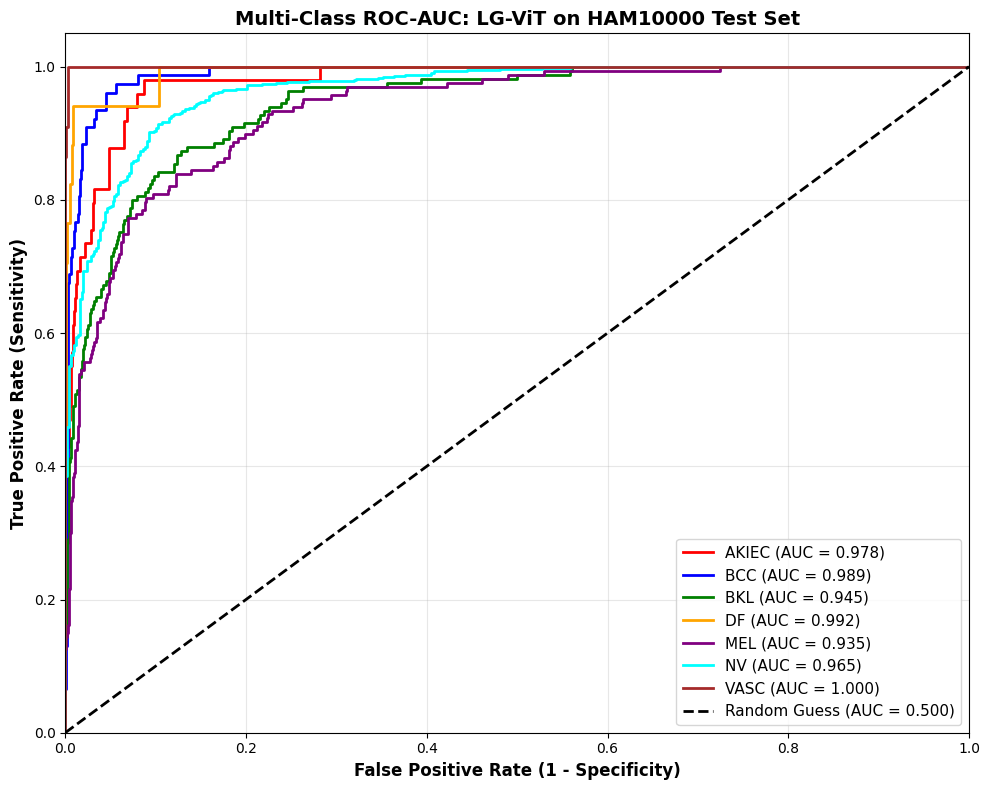

🎯 Macro-Average ROC-AUC across all 7 classes: 0.9724


In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import torch
from tqdm import tqdm

# 1. Load the best test-ready weights
model.load_state_dict(torch.load('/kaggle/working/best_lgvit_test_ready.pth'))
model.eval()

all_labels = []
all_probs = []

# 2. Extract raw probabilities
print("🔍 Running Inference for ROC-AUC...")
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Extracting Probabilities"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        
        # Apply Softmax to get probabilities (0.0 to 1.0)
        probs = torch.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# 3. Binarize labels for multi-class One-vs-Rest (OvR) evaluation
y_test_bin = label_binarize(all_labels, classes=list(range(num_classes)))

# 4. Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 5. Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'brown']

for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i].upper()} (AUC = {roc_auc[i]:.3f})')

# Plot the 50/50 random guess line
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess (AUC = 0.500)')

# Formatting the chart
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
plt.title('Multi-Class ROC-AUC: LG-ViT on HAM10000 Test Set', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

# Save the high-res image for your GitHub / Thesis
plt.savefig('/kaggle/working/ham10000_roc_auc.png', dpi=300)
print("\n✅ ROC-AUC Graph saved as 'ham10000_roc_auc.png' in Kaggle working directory.")
plt.show()

# 6. Compute Macro-Average ROC-AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes

macro_roc_auc = auc(all_fpr, mean_tpr)
print(f"🎯 Macro-Average ROC-AUC across all 7 classes: {macro_roc_auc:.4f}")

✅ Successfully generated 'ham10000_attention_maps.png'. Check your Kaggle Output folder.


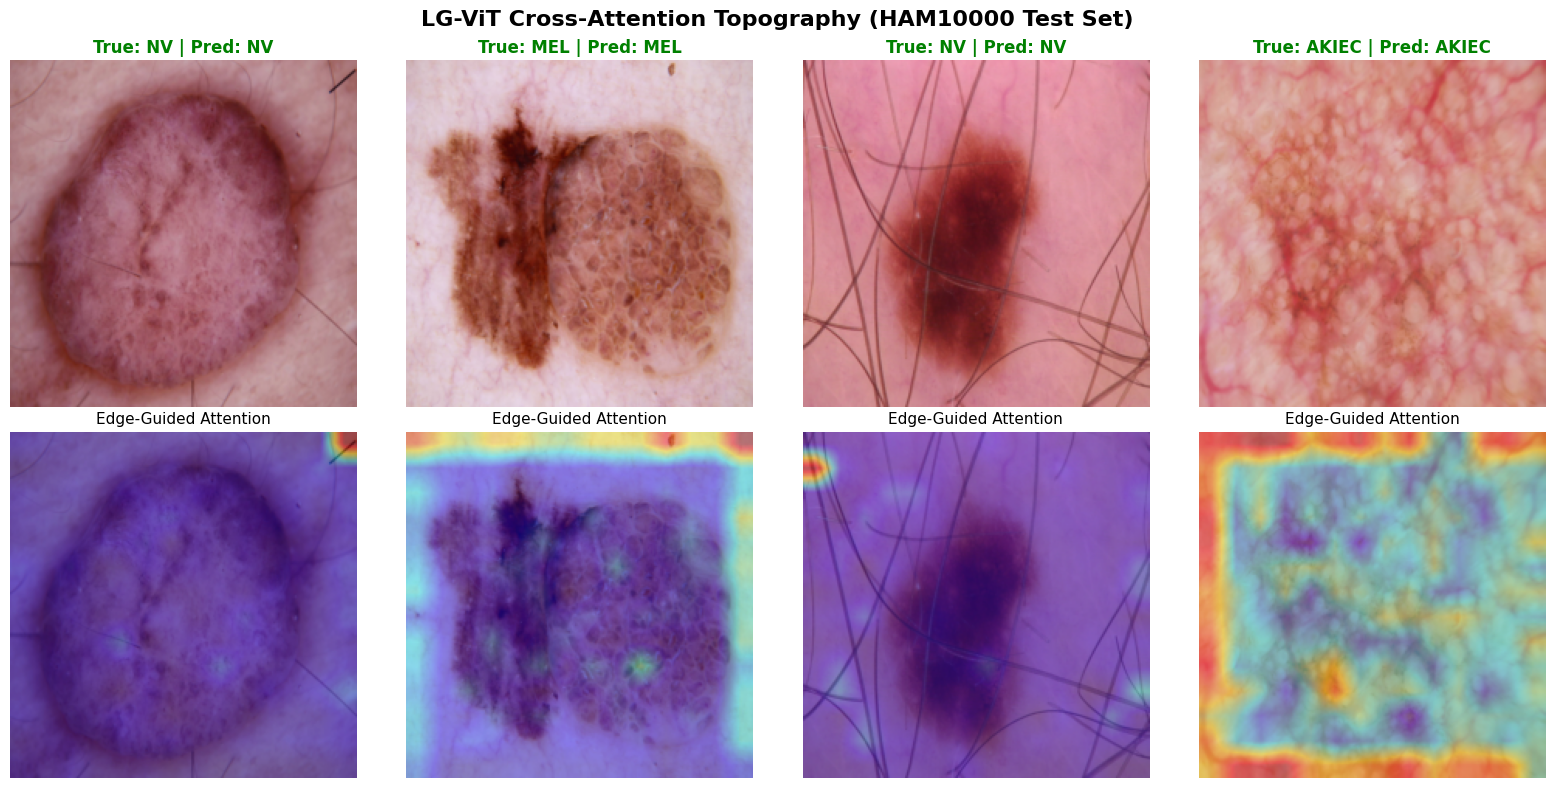

In [4]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import cv2
import pandas as pd
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from PIL import Image
import timm

# ==========================================
# 1. RE-DEFINE ARCHITECTURE
# ==========================================
class LaplacianEdgeExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        laplacian = torch.tensor([[0,  1, 0], [1, -4, 1], [0,  1, 0]], dtype=torch.float32).view(1, 1, 3, 3)
        self.laplacian = nn.Parameter(laplacian, requires_grad=False)

    def forward(self, x):
        return torch.nn.functional.conv2d(x.mean(dim=1, keepdim=True), self.laplacian, padding=1)

class LG_ViT_Production(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.vit = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=0)
        self.embed_dim = self.vit.num_features
        self.edge_extractor = LaplacianEdgeExtractor()
        self.edge_patch_embed = nn.Conv2d(1, self.embed_dim, kernel_size=16, stride=16)
        self.cross_attn = nn.MultiheadAttention(embed_dim=self.embed_dim, num_heads=4, batch_first=True)
        self.layer_norm = nn.LayerNorm(self.embed_dim)
        self.classifier = nn.Sequential(
            nn.Linear(self.embed_dim * 2, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        rgb_tokens = self.vit.forward_features(x)
        edges = self.edge_extractor(x)
        edge_tokens = torch.cat([torch.zeros(x.shape[0], 1, self.embed_dim, device=x.device), 
                                 self.edge_patch_embed(edges).flatten(2).transpose(1, 2)], dim=1)
        attn_out, _ = self.cross_attn(query=rgb_tokens, key=edge_tokens, value=edge_tokens)
        fused = self.layer_norm(rgb_tokens + attn_out)
        return self.classifier(torch.cat([rgb_tokens[:, 0, :], fused[:, 0, :]], dim=-1))

# ==========================================
# 2. LOAD MODEL & REGISTER HOOK
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LG_ViT_Production(num_classes=7).to(device)
model.load_state_dict(torch.load('/kaggle/working/best_lgvit_test_ready.pth'))
model.eval()

attention_maps = {}
def get_attention_hook(name):
    def hook(module, input, output):
        attention_maps[name] = output[1].detach().cpu()
    return hook

model.cross_attn.register_forward_hook(get_attention_hook('cross_attn'))

# ==========================================
# 3. GET A TEST BATCH
# ==========================================
base_path = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
csv_path = os.path.join(base_path, 'HAM10000_metadata.csv')

image_path_map = {f: os.path.join(root, f) for root, dirs, files in os.walk(base_path) for f in files if f.endswith('.jpg')}
df = pd.read_csv(csv_path)
class_names = sorted(df['dx'].unique().tolist())
label_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}

# Quick reproducible split to grab test images
df_train, df_temp = train_test_split(df, test_size=0.30, random_state=42, stratify=df['dx'])
df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=42, stratify=df_temp['dx'])

class DirectHAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(image_path_map[f"{row['image_id']}.jpg"]).convert("RGB")
        return self.transform(image), label_to_idx[row['dx']]

transform_test = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

viz_loader = DataLoader(DirectHAM10000Dataset(df_test, transform_test), batch_size=8, shuffle=True)
images, labels = next(iter(viz_loader))
images = images.to(device)

# ==========================================
# 4. RUN INFERENCE & PLOT HEATMAPS
# ==========================================
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

attn_weights = attention_maps['cross_attn']

num_viz = 4
fig, axes = plt.subplots(2, num_viz, figsize=(16, 8))
fig.suptitle('LG-ViT Cross-Attention Topography (HAM10000 Test Set)', fontsize=16, fontweight='bold')

inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

for i in range(num_viz):
    img_tensor = images[i].cpu()
    img_rgb = inv_normalize(img_tensor).permute(1, 2, 0).numpy()
    img_rgb = np.clip(img_rgb, 0, 1)
    
    true_label = class_names[labels[i].item()].upper()
    pred_label = class_names[preds[i].item()].upper()
    color = 'green' if true_label == pred_label else 'red'
    
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(f"True: {true_label} | Pred: {pred_label}", color=color, fontweight='bold')
    axes[0, i].axis('off')
    
    # Process Attention Map (Skip the CLS token, reshape 196 -> 14x14)
    cls_attention = attn_weights[i, 0, 1:].numpy()
    attn_grid = cls_attention.reshape(14, 14)
    attn_grid = (attn_grid - attn_grid.min()) / (attn_grid.max() - attn_grid.min() + 1e-8)
    
    heatmap = cv2.resize(attn_grid, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    overlay = cv2.addWeighted(np.uint8(255 * img_rgb), 0.6, heatmap, 0.4, 0)
    
    axes[1, i].imshow(overlay)
    axes[1, i].set_title("Edge-Guided Attention", fontsize=11)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/ham10000_attention_maps.png', dpi=300)
print("✅ Successfully generated 'ham10000_attention_maps.png'. Check your Kaggle Output folder.")
plt.show()

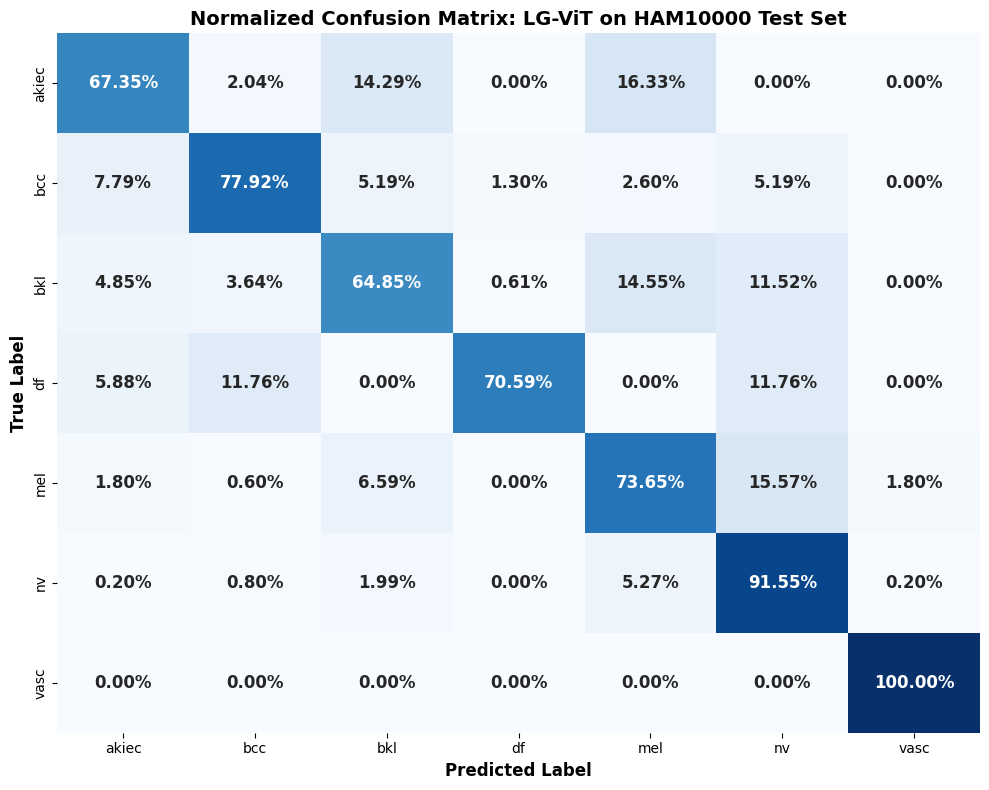

✅ Successfully generated and saved: ./ham10000_confusion_matrix.png


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# GENERATE & SAVE HAM10000 CONFUSION MATRIX
# ==========================================

# 1. Define the exact class order from your Kaggle output
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

# 2. Compute the Normalized Confusion Matrix
cm = confusion_matrix(all_labels, all_preds, normalize='true')

# 3. Configure the Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar=False, annot_kws={'size': 12, 'weight': 'bold'})

# 4. Styling and Labels
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Normalized Confusion Matrix: LG-ViT on HAM10000 Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()

# 5. Save the Output to Kaggle's working directory
cm_path = './ham10000_confusion_matrix.png'
plt.savefig(cm_path, dpi=300)
plt.show()

print(f"✅ Successfully generated and saved: {cm_path}")